In [51]:
import operator
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field

In [52]:
load_dotenv()

True

In [53]:
generator_llm = ChatGroq(
    model = 'llama-3.3-70b-versatile',
    temperature= 0
)

evaluator_llm = ChatGroq(
    model = 'llama-3.3-70b-versatile',
    temperature= 0
)

optimizer_llm = ChatGroq(
    model = 'llama-3.3-70b-versatile',
    temperature= 0
)

In [54]:
class PostEvaluation(BaseModel):
    post : Literal['approved', 'need_improvement'] = Field(description= 'Tell me about the status of the post is it good or need improvement.')
    feedback : str = Field(description= 'Tell me about the quality and importance of post.')    

In [55]:
struct_model = evaluator_llm.with_structured_output(PostEvaluation)

In [56]:
class PostState(TypedDict):
    topic : str
    description : str
    evaluation : Literal['approved', 'need_improvement']
    feedback : str
    iteration : int # How many loops run in-order to improve the description of topic.
    max_iteration : int

    description_history : Annotated[list[str] , operator.add]
    feedback_history : Annotated[list[str] , operator.add]

In [ ]:
def generate_description(state : PostState):
    prompt = [
        SystemMessage(content= 'Act as a mature linkedin user whose main motive is to attract more followers through his content.'),
        HumanMessage(content= f'''Write a description on the topic of {state['topic']} and make sure to follow the below rules.
        -Rule:
        Make sure that description is not longer than 500 chars.
        Do not use question answer format.
        Make the description sounds more humanize
        Also use some emojis to make it eye catchy.''')
    ]

    description = generator_llm.invoke(prompt).content
    return {'description' : description}

In [ ]:
def evaluate_description(state : PostState):
    prompt = [SystemMessage(content= 'You are a description generator assistant and make sure that description is evaluated based on its parameters'),
              HumanMessage(content= f'''Evaluate the description {state['description']} based on the below criteria.
            - Criteria:
            Make the description easy to understand even for a layman.
            It is well formated.
            Make it to the point, punchy, and attention grabing.
            It will fulfill the guidlines and didnot overcome these guidlines.''')
            ]
    
    response = struct_model.invoke(prompt)
# In return '.post' & '.feedback' came from PostEvaluation class.
    return {'evaluation' : response.post, 'feedback' : response.feedback , 'feedback_history' : [response.feedback]}

In [59]:
def optimize_description(state : PostState):
    prompt = [
        SystemMessage(content= 'You are a description generator assistant and help me to optimize the description so it is considered good and at point!'),
        HumanMessage(content= f'''Optimize the generated description {state['description']} based on its feedback {state['feedback']}
        Rewrite it if it does not fit in the your rules and crietria. ''')
    ]

    response = optimizer_llm.invoke(prompt).content
    iteration = state['iteration'] + 1
    return {'description' : response, 'iteration' : iteration, 'description_history' :[response]}

In [60]:
def route_evaluation(state : PostState):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'need_improvement'

In [ ]:
graph = StateGraph(PostState)

graph.add_node('generate_description', generate_description)
graph.add_node('evaluate_description', evaluate_description)
graph.add_node('optimize_description', optimize_description)

graph.add_edge(START, 'generate_description')
graph.add_edge('generate_description', 'evaluate_description')

graph.add_conditional_edges('evaluate_description', route_evaluation, {'approved' : END, 'need_improvement' : 'optimize_description'})

graph.add_edge('optimize_description', END)

workflow = graph.compile()

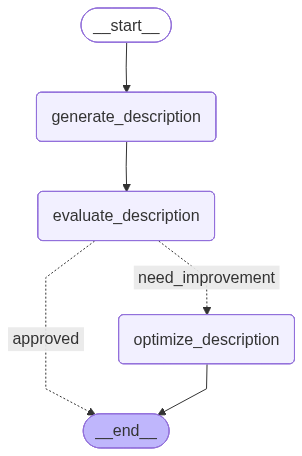

In [62]:
workflow

In [63]:
user_statement = {
    'topic' : 'Sklearn framework in machine learning!',
    'iteration' : 3,
    'max_iteration' : 6
}

workflow.invoke(user_statement)

{'topic': 'Sklearn framework in machine learning!',
 'description': '"Boost your machine learning skills with Scikit-learn 🚀! This popular Python framework offers a wide range of algorithms for classification, regression, clustering, and more 🤖. With its simple and efficient tools, you can easily implement and compare different models 📊. Scikit-learn is a game-changer for data scientists and developers alike 💻. Let\'s dive in and explore its capabilities! 💡" #ScikitLearn #MachineLearning #Python',
 'evaluation': 'approved',
 'feedback': 'The description is well-formatted, easy to understand, and attention-grabbing. It effectively conveys the benefits of using Scikit-learn for machine learning tasks and is concise and to the point. The use of emojis adds a touch of personality and makes the description more engaging. Overall, the description meets the guidelines and is well-suited for its intended purpose.',
 'iteration': 3,
 'max_iteration': 6,
 'description_history': [],
 'feedback_hi